In [1]:
# enable lokal import
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent  
SRC_DIR = ROOT_DIR / "src"

sys.path.insert(0, str(SRC_DIR)) 

%matplotlib inline
import matplotlib.pyplot as plt
plt.ioff()

#### Initial state  and martices for constructing the J gate 

In [2]:
from ewl import EWL

from ewl.parametrizations import U_theta_alpha_beta

import sympy as sp
from sympy import Array, Matrix
from sympy.physics.quantum.qubit import Qubit


from qiskit.visualization import plot_histogram

sp.init_printing()

i = sp.I
pi = sp.pi
sqrt2 = sp.sqrt(2)

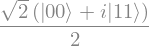

In [3]:
psi = (Qubit('00') + i * Qubit('11')) / sqrt2
psi

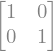

In [4]:
C = Matrix([
    [1, 0],
    [0, 1],
])
C

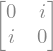

In [5]:
D = Matrix([
    [0, i],
    [i, 0],
])
D

#### Payoff matrix

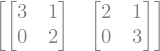

In [6]:
payoff_matrix = Array([
    [
        [3, 1],
        [0, 2],
    ],
    [
        [2, 1],
        [0, 3],
    ],
])
payoff_matrix

#### Pauli matrices  

In [7]:
I= Matrix([
    [1, 0],
    [0, 1],
])

In [8]:
X= Matrix([
    [0, 1],
    [1, 0],
])

In [9]:
Y= Matrix([
    [0, -i],
    [i, 0],
])

In [10]:
Z=Matrix([
    [1, 0],
    [0, -1],
])

#### Player strategies

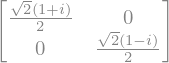

In [11]:
U3 = (I+i*Z)/ sqrt2
U3

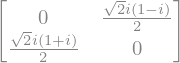

In [12]:
U4 = i*(X+Y)/sqrt2
U4

### (iX, iX) strategy - symbolic execution step by step

In [13]:
alice=i*X
bob=i*X

In [14]:
ewl = EWL(psi=psi, C=C, D=D, players=[alice, bob], payoff_matrix=payoff_matrix)
ewl

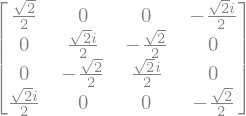

In [15]:
ewl.J

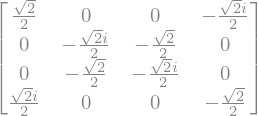

In [16]:
ewl.J_H

In [17]:
ewl.amplitudes(simplify=False)

In [18]:
ewl.amplitudes()

In [19]:
ewl.probs()

In [20]:
(ewl.payoff_function(player=0), ewl.payoff_function(player=1))

#### Different strategies test
$$
\begin{array}{c|cccc}
 & I & iX & U_3 & U_4 \\
\hline
I & (3,2) & (1,1) & \left(\frac{5}{2},\frac{5}{2}\right) & \left(\frac{1}{2},\frac{1}{2}\right) \\
iX & (0,0) & (2,3) & \left(\frac{1}{2},\frac{1}{2}\right) & \left(\frac{5}{5},\frac{5}{5}\right) \\
U_3 & \left(\frac{5}{2},\frac{5}{2}\right) & \left(\frac{1}{2},\frac{1}{2}\right) & (2,3) & (0,0) \\
U_4 & \left(\frac{1}{2},\frac{1}{2}\right) & \left(\frac{5}{2},\frac{5}{2}\right) & (1,1) & (3,2) \\
\end{array}
$$

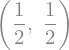

In [41]:
alice=i*X
bob=(I+i*Z)/ sqrt2
ewl = EWL(psi=psi, C=C, D=D, players=[alice, bob], payoff_matrix=payoff_matrix)
(ewl.payoff_function(player=0), ewl.payoff_function(player=1))


#### Probabilities

In [42]:
ewl.probs()

### Statevector simulator IBM

In [43]:
from ewl.ibmq import EWL_IBMQ
ewl_ibmq = EWL_IBMQ(ewl)
ewl_ibmq

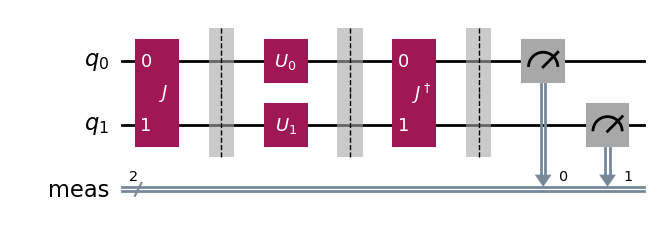

In [44]:
ewl_ibmq.draw()


{np.str_('01'): np.float64(0.5000000000000002), np.str_('10'): np.float64(0.5000000000000002)}


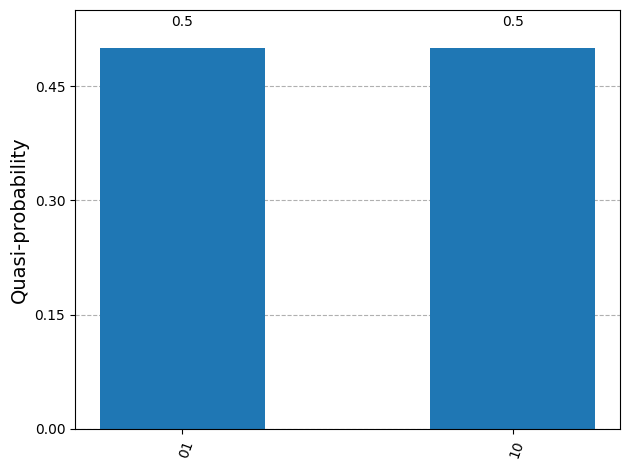

In [45]:
probs = ewl_ibmq.simulate_probs()
print(probs)
plot_histogram(probs)

{np.str_('01'): np.int64(522), np.str_('10'): np.int64(502)}


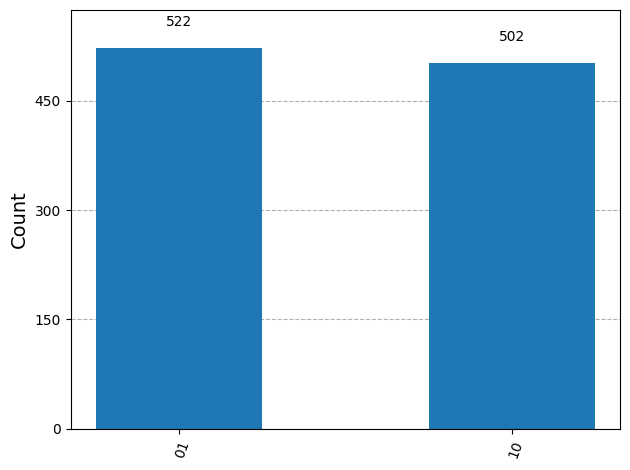

In [46]:
counts_qasm_simulator = ewl_ibmq.simulate_counts()
print(counts_qasm_simulator)
plot_histogram(counts_qasm_simulator)

### Transpiled circuit preview

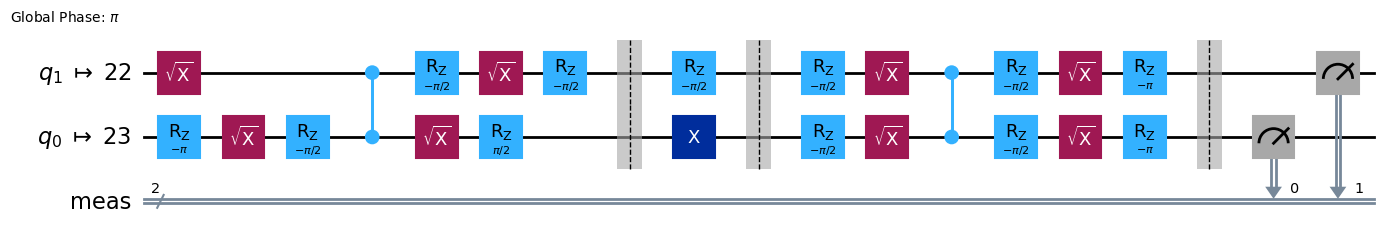

In [47]:
ewl_ibmq.draw_transpiled(backend_name='ibm_fez', optimization_level=3, fold=-1)

### Actual Run

In [48]:
counts_quantum_device = ewl_ibmq.run(tries=100)
print(counts_quantum_device)
#plot_histogram(counts_quantum_device)

[{'10': 505, '01': 501, '11': 6, '00': 12}, {'01': 523, '10': 487, '00': 9, '11': 5}, {'01': 497, '10': 512, '11': 6, '00': 9}, {'10': 516, '01': 492, '00': 10, '11': 6}, {'10': 495, '01': 507, '11': 11, '00': 11}, {'01': 522, '10': 482, '00': 10, '11': 10}, {'01': 493, '10': 518, '00': 6, '11': 7}, {'01': 482, '10': 517, '11': 14, '00': 11}, {'01': 493, '10': 516, '00': 5, '11': 10}, {'10': 511, '01': 497, '11': 9, '00': 7}, {'10': 496, '01': 515, '00': 6, '11': 7}, {'01': 521, '10': 490, '00': 8, '11': 5}, {'01': 502, '10': 503, '00': 7, '11': 12}, {'10': 498, '01': 513, '00': 6, '11': 7}, {'01': 486, '10': 532, '00': 4, '11': 2}, {'10': 503, '01': 505, '00': 7, '11': 9}, {'10': 481, '01': 524, '00': 13, '11': 6}, {'01': 491, '10': 517, '00': 7, '11': 9}, {'01': 483, '10': 521, '00': 13, '11': 7}, {'01': 485, '10': 522, '11': 7, '00': 10}, {'10': 504, '01': 503, '11': 10, '00': 7}, {'01': 504, '10': 508, '11': 6, '00': 6}, {'01': 531, '10': 477, '00': 6, '11': 10}, {'10': 522, '01': 

In [49]:
with open('wyniki_czysta.txt', 'w') as plik:
    for element in counts_quantum_device:
        plik.write(str(dict(sorted(element.items()))) + '\n')

In [ ]:
binary_prob = [probs, counts_qasm_simulator, counts_quantum_device]
plot_histogram(
    binary_prob,
    bar_labels=False,
    legend=['ideal distribution', 'simulator (sampling)', 'real quantum device']       
)